# 1. MLP  + Activation Functions

Feed Forward Propagation and Backpropagation

Pytorch PowerYe

### Libraries

In [1]:
# !pip install torchinfo

In [2]:
# !pip install torch

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


### 1. MLP(Multi-layer Percepton)

In [4]:
# Xor Data

In [5]:
X = torch.tensor([
    [0.,0.],
    [0.,1.],
    [1.,0.],
    [1.,1.]
])
y = torch.tensor([[0.],[1.],[1.],[0.]])

In [6]:
X.shape

torch.Size([4, 2])

In [7]:
y.shape

torch.Size([4, 1])

In [8]:
X.dtype

torch.float32

In [9]:
# Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2,10)
        self.fc2 = nn.Linear(10,5)
        self.fc3 = nn.Linear(5,1)
        #self.dropout1 = nn.Dropout(p=0.2)
    def forward(self,x):
        x = torch.relu(self.fc1(x))
        #x = self.fc1(x)
        x = torch.relu(self.fc2(x))
        #x = self.dropout1(x)

        x = self.fc3(x)
        return x

In [10]:
model = MLP()
#from torchinfo import summary
#summary(model)
model

MLP(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=5, bias=True)
  (fc3): Linear(in_features=5, out_features=1, bias=True)
)

In [11]:
for name, param in model.named_parameters():
    print(name, param)

fc1.weight Parameter containing:
tensor([[-3.1504e-01, -4.1879e-01],
        [ 4.6437e-01,  4.2193e-01],
        [-6.3240e-01,  1.3849e-01],
        [-4.8219e-01, -9.0095e-02],
        [ 4.4414e-01, -5.7933e-01],
        [-3.0492e-02,  2.8262e-01],
        [-4.7843e-01, -1.4133e-01],
        [ 6.5649e-01,  6.2446e-02],
        [ 5.0476e-01, -4.3239e-01],
        [-5.5752e-04,  1.4488e-02]], requires_grad=True)
fc1.bias Parameter containing:
tensor([-0.6970, -0.0385, -0.6627, -0.5544,  0.0957,  0.6480, -0.3624,  0.5973,
        -0.4428,  0.5808], requires_grad=True)
fc2.weight Parameter containing:
tensor([[ 0.2161,  0.3142, -0.2740, -0.1863,  0.2546, -0.1302,  0.1184, -0.1864,
          0.2324, -0.1586],
        [ 0.2989,  0.1490, -0.1822, -0.0029,  0.1773, -0.0550,  0.1774,  0.1283,
          0.2515, -0.1169],
        [-0.1329, -0.2379,  0.1715,  0.2212,  0.2385, -0.2958, -0.2890, -0.0788,
          0.1800, -0.1610],
        [ 0.0454, -0.0436, -0.2119,  0.0527, -0.1914,  0.0025,  0.14

In [12]:
# Train
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(2000):
    optimizer.zero_grad()
    out = model(X)
    #print(out)
    loss = criterion(out,y)
    loss.backward()
    optimizer.step()

    if (epoch+1)%400==0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 400, Loss: 0.4875
Epoch 800, Loss: 0.4784
Epoch 1200, Loss: 0.4778
Epoch 1600, Loss: 0.4777
Epoch 2000, Loss: 0.4776


In [13]:

x = torch.tensor(2.0, requires_grad=True)
y1 = x * x + 3*x + 5
y1.backward()

print(x.grad)


tensor(7.)


In [14]:
# Test
with torch.no_grad():
    probs = torch.sigmoid(model(X))
    preds = (probs>0.5).float()

print("Probabilities:\n", probs)
print("Classes:\n", preds)

Probabilities:
 tensor([[0.3336],
        [0.3336],
        [0.9992],
        [0.3336]])
Classes:
 tensor([[0.],
        [0.],
        [1.],
        [0.]])


In [15]:
#updated

In [16]:
for name, param in model.named_parameters():
    print(f"{name}:\n{param.detach().numpy()}\n")

fc1.weight:
[[-0.3150379  -0.4187882 ]
 [ 0.2703449   0.63342595]
 [-0.6324037   0.13849193]
 [-0.48218632 -0.09009521]
 [ 1.3236141  -1.3719522 ]
 [-0.409753    0.61044306]
 [-0.4784276  -0.1413252 ]
 [ 0.88649017 -0.21279673]
 [ 0.8146506  -0.5793353 ]
 [-0.07656191  0.06117127]]

fc1.bias:
[-0.6970002  -0.26456454 -0.6626609  -0.5544394   0.02738001  0.692181
 -0.3623593   0.54252046 -0.13293052  0.5845251 ]

fc2.weight:
[[ 0.21613517  0.3142196  -0.2739835  -0.18627149  0.254633   -0.13024959
   0.11842757 -0.18641569  0.23244531 -0.15863286]
 [ 0.2988704  -0.08975013 -0.18215466 -0.0028901   0.8933802  -0.22397137
   0.1773954   0.10458974  0.49188128 -0.1686741 ]
 [-0.13285221 -0.21816176  0.17146084  0.2211597   0.7452394  -0.44408306
  -0.28903311  0.27708027  0.39383066 -0.18882786]
 [ 0.04540416 -0.04358281 -0.21193965  0.05273119 -0.1913685   0.00254913
   0.14672987  0.02955041 -0.0389289  -0.11801249]
 [ 0.2424426  -0.46585143  0.15818216  0.06971046  1.3500335  -0.6414206

# Task Lab

In [17]:
# Data

In [18]:
# Combined dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

### ###  Normalizing the Data

Before building your model, you will apply a quick data preparation step called **normalization**. This is a standard technique that makes the training process more stable and effective by adjusting the scale of the data. This adjustment helps prevent large distance values from dominating the learning process and keeps gradients stable during training. You will explore this topic in greater detail in a later module.

* You will calculate the mean and standard deviation for the `distances` and `times` tensors.
* You will then apply standardization to each tensor using its respective mean and standard deviation, which creates new normalized tensors named `distances_norm` and `times_norm`.
* This specific technique is called **standardization** (or z-score normalization), which converts the original data from `1.0 to 20.0 miles` and approximately `7 to 93 minutes` into a new, normalized scale.

In [19]:
# Calculate the mean and standard deviation for the 'distances' tensor
distances_mean = distances.mean()
distances_std = distances.std()

# Calculate the mean and standard deviation for the 'times' tensor
times_mean = times.mean()
times_std = times.std()

# Apply standardization to the distances.
distances_norm = (distances - distances_mean) / distances_std

# Apply standardization to the times.
times_norm = (times - times_mean) / times_std

In [20]:
## Building the Non-Linear Model
# Build model with 4 layers
class NonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

model_2 = NonLinearModel()
model_2


NonLinearModel(
  (fc1): Linear(in_features=1, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=1, bias=True)
)

In [21]:
# Define the loss function and optimizer
loss_function = nn.MSELoss()
optimizer = optim.Adam(model_2.parameters(), lr=0.01)


In [22]:
loss_function = nn.MSELoss()
optimizer = optim.Adam(model_2.parameters(), lr=0.01)  # SGD, Adam


In [23]:
from IPython.display import clear_output
import time
def plot_training_progress(epoch, loss, model_2, distances_norm, times_norm):
    """
    Plots the training progress of a model on normalized data,
    showing the current fit at each epoch.

    Args:
        epoch: The current training epoch number.
        loss: The loss value at the current epoch.
        model: The model being trained.
        distances_norm: The normalized input data.
        times_norm: The normalized target data.
    """
    # Clear the previous plot from the output cell
    clear_output(wait=True)

    # Make predictions using the current state of the model
    predicted_norm = model_2(distances_norm)

    # Convert tensors to NumPy arrays for plotting
    x_plot = distances_norm.numpy()
    y_plot = times_norm.numpy()

    # Detach predictions from the computation graph and convert to NumPy
    y_pred_plot = predicted_norm.detach().numpy()

    # Sort the data based on distance to ensure a smooth line plot
    sorted_indices = x_plot.argsort(axis=0).flatten()

    # Create a new figure for the plot
    plt.figure(figsize=(8, 6))

    # Plot the original normalized data points
    plt.plot(x_plot, y_plot, color='orange', marker='o', linestyle='none', label='Actual Normalized Data')

    # Plot the model's predictions as a line
    plt.plot(x_plot[sorted_indices], y_pred_plot[sorted_indices], color='green', label='Model Predictions')

    # Set the title of the plot, including the current epoch
    plt.title(f'Epoch: {epoch + 1} | Normalized Training Progress')
    # Set the x-axis label
    plt.xlabel('Normalized Distance')
    # Set the y-axis label
    plt.ylabel('Normalized Time')
    # Display the legend
    plt.legend()
    # Add a grid to the plot
    plt.grid(True)
    # Show the plot
    plt.show()

    # Pause briefly to allow the plot to be rendered
    time.sleep(0.05)


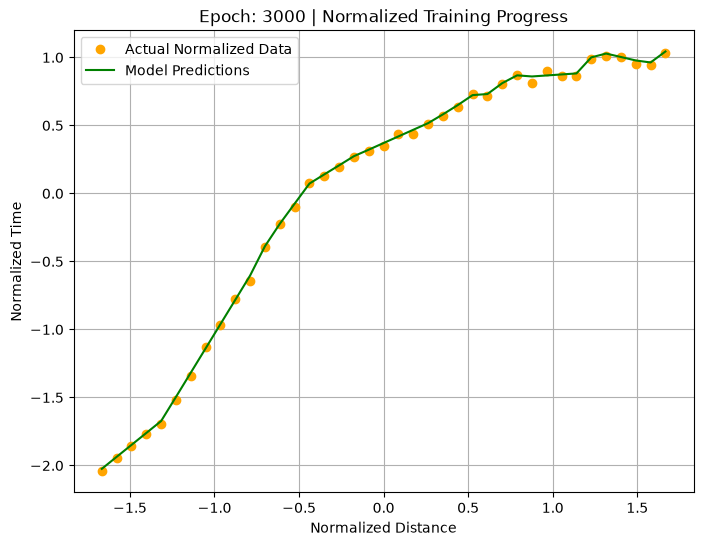


Training Complete.

Final Loss: 0.0003237730707041919


In [24]:
# Training loop
for epoch in range(3000):
    # Reset the optimizer's gradients
    optimizer.zero_grad()
    # Make predictions (forward pass)
    outputs = model_2(distances_norm)
    # Calculate the loss
    loss = loss_function(outputs, times_norm)
    # Calculate adjustments (backward pass)
    loss.backward()
    # Update the model's parameters
    optimizer.step()

    # Create a live plot every 50 epochs
    if (epoch + 1) % 50 == 0:
        plot_training_progress(
            epoch=epoch,
            loss=loss,
            model_2=model_2,
            distances_norm=distances_norm,
            times_norm=times_norm
        )

print("\nTraining Complete.")
print(f"\nFinal Loss: {loss.item()}")


## Making a Prediction

With your fully trained non-linear model, you can now use it to make a prediction for a new delivery. The process is slightly different now because your model was trained on *normalized* data.

* First, you will take the new input distance and **normalize** it using the same mean and standard deviation from your training data. This step is CRITICAL: your model has no idea about the original scales (miles and minutes). It only understands the normalized scale it was trained on.
* After the model provides its prediction, you must **de-normalize** the output. This converts the prediction from its normalized scale back into an understandable value in minutes.
* Finally, the code uses this actual predicted time to run the decision logic. For this prediction, assume your company now promises deliveries within 45 minutes and wants to know which vehicle to use. if distance less than 30 meters bike else car

In [25]:
# distance_to_predict = --------write here
distance_to_predict = 2.5


In [26]:
# Use the torch.no_grad() context manager for efficient prediction
with torch.no_grad():
    # Normalize the input distance
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distances_mean) / distances_std

    # Get the normalized prediction from the model
    predicted_time_norm = model_2(new_distance_norm)

    # De-normalize the output to get the actual time in minutes
    predicted_time_actual = (predicted_time_norm * times_std) + times_mean

    # --- Decision Making Logic ---
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")

    # First, check if the delivery is possible within the 45-minute timeframe
    if predicted_time_actual.item() > 45:
        print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
    else:
        # If it is possible, then determine the vehicle based on the distance
        if distance_to_predict <= 3:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
        else:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")


Prediction for a 2.5-mile delivery: 14.9 minutes

Decision: Yes, delivery is possible. Since the distance is 2.5 miles (<= 3 miles), use a bike.
